<h1><center>

</center></h1>
<font size="6"><center>
EIE 401
PROCESAMIENTO DIGITAL MULTIMEDIA 
</center></font>


<center><h2>Proyecto 1</h2></center>
<center><h3>Procesamiento digital de señales</h3></center>
<center><h3>Profesor: Jorge Cardenas</h3></center>

<center><h3>Por: Karen Ingala</h3></center>
<center><h5>Pontificia Universidad Catolica de Valparaiso</h5></center>
 

In [1]:
from IPython.display import IFrame, display
filepath = "Proyecto_1_EIE401.pdf"
IFrame(filepath, width=700, height=400)

Debes usar el sitio https://gwosc.org/eventapi/html/GWTC/, donde encuentras todo el catálogo de observaciones con los datos en diferentes formatos. Debes seleccionar una detección para tu estudio y descargar los datos correspondientes (H5 o TXT), lo que posteriormente deberás tratar de manera digital como audio (serie de tiempo).
tip: Te recomiendo tomar la serie de tiempo corta (32 segundos) para facilitar el análisis, y asegurarte de tomar la tasa de muestreo más alta.
tip: Asegúrate de tomar un caso cuyo espectrograma de muestra, indique una señal clara y fuerte para facilitar tu trabajo, de otra forma es posible que no logres aislarla lo suficiente.


## 1. Carga de Datos


In [4]:
import sys
!{sys.executable} -m pip install h5py numpy matplotlib scipy

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   -------------------------- ------------- 2.1/3.2 MB 11.7 MB/s eta 0:00:01
   ----------------------------- ---------- 2.4/3.2 MB 6.4 MB/s eta 0:00:01
   ----------------------------- ---------- 2.4/3.2 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 4.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


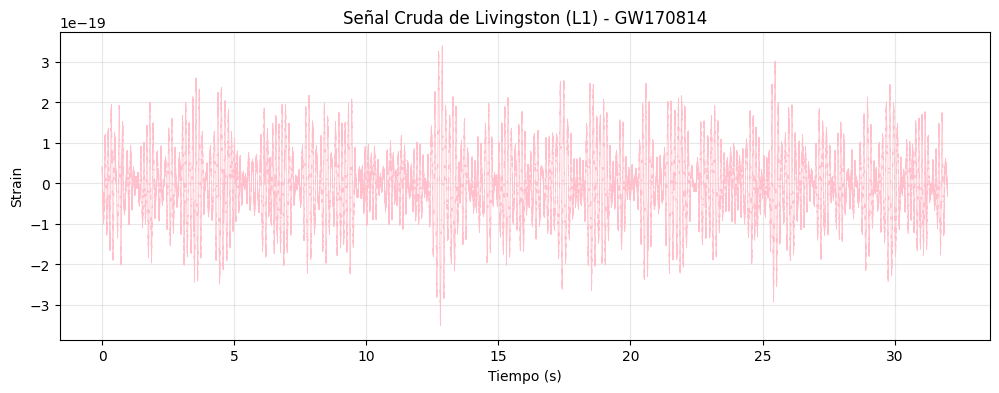

Detección cargada con éxito: 32 segundos a 4096 Hz.


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

archivo = 'L-L1_GWOSC_4KHZ_R1-1186741846-32.hdf5' 

#Cargar datos 
with h5py.File(archivo, 'r') as f:
    strain = f['strain']['Strain'][:]
    # Usamos la metadata del archivo para el tiempo
    dt = f['strain']['Strain'].attrs['Xspacing']
    fs = int(1/dt) # Esto nos da los 4000 Hz
    duration = f['meta']['Duration'][()]
    time = np.arange(0, duration, dt)

#Graficar (Señal Cruda)
plt.figure(figsize=(12, 4))
plt.plot(time, strain, color='pink', linewidth=0.5)
plt.title('Señal Cruda de Livingston (L1) - GW170814')
plt.xlabel('Tiempo (s)')
plt.ylabel('Strain')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Detección cargada con éxito: {duration} segundos a {fs} Hz.")

## 2. Convertir en audio
Es una forma de validar que tenemos un alto componente de ruido en la señal y que el interés es eliminarlo para encontrar una señal candidata.

Te recomiendo hacer una señal de audio de cada uno de las etapas para así validar como va el proceso. Al final deberás obtener un señal con CHIRP o BUMP. Son sonidos que comprueban que tienes una cantidad de potencia que sobre destaca sobre el ruido.

In [ ]:
from scipy.io import wavfile

# Normalización: los valores de strain son mínimos (1e-19), 
# debemos escalarlos al rango -1 a 1 para que sean audibles.
strain_audible = strain / np.max(np.abs(strain))

# Guardamos el archivo .wav
wavfile.write('ruido_original_L1.wav', fs, strain_audible.astype(np.float32))

print("Audio de la señal cruda generado. Escucharás un estruendo de baja frecuencia.")

import IPython.display as ipd

# Cargar el reproductor
print("Reproduciendo: Ruido Original (Señal Cruda)")
ipd.display(ipd.Audio('ruido_original_L1.wav'))

Audio de la señal cruda generado. Escucharás un estruendo de baja frecuencia.
Reproduciendo: Ruido Original (Señal Cruda)


## 3. Análisis de Fourier
Al realizar la conversión, queremos ver cuales son las componentes de ruido que más afectan al instrumento y debemos ignorar en el análisis. Eso se ve como "pico" o la apariencia de "peine".
Se debe presenta la densidad espectral de potencia antes y después de la función de Windowing.


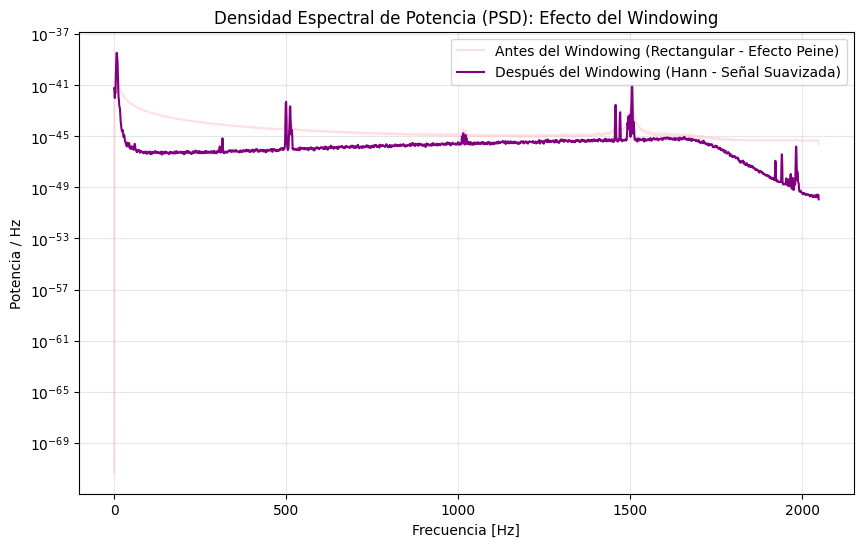

Audio 1.5: Señal con Ventana de Hann (Análisis de Fourier)


In [ ]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

# ANÁLISIS DE FOURIER: COMPARACIÓN DE PSD (Windowing)

# 1. Calculamos la PSD ANTES del Windowing
# muestra el ruido crudo y las fugas espectrales.
f_crudo, psd_crudo = signal.welch(strain, fs=fs, window='boxcar', nperseg=fs)

# 2. Calculamos la PSD DESPUÉS del Windowing (Usando ventana de Hann)
f_psd, psd_l1 = signal.welch(strain, fs=fs, window='hann', nperseg=fs, noverlap=fs//2)

#COMPARACIÓN
plt.figure(figsize=(10, 6))

# Graficamos ambas en escala logarítmica para notar la diferencia
plt.semilogy(f_crudo, psd_crudo, color='pink', alpha=0.5, label='Antes del Windowing (Rectangular - Efecto Peine)')
plt.semilogy(f_psd, psd_l1, color='purple', label='Después del Windowing (Hann - Señal Suavizada)')

plt.title('Densidad Espectral de Potencia (PSD): Efecto del Windowing')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia / Hz')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

# VALIDACIÓN AUDITIVA: Señal con Windowing (Sección 3)
ventana = np.hanning(len(strain))
strain_windowed = strain * ventana

# Normalización para que sea audible
strain_audible_hann = strain_windowed / np.max(np.abs(strain_windowed))

# Guardar y mostrar reproductor
wavfile.write('1.5_senal_con_hann.wav', fs, strain_audible_hann.astype(np.float32))

print("Audio 1.5: Señal con Ventana de Hann (Análisis de Fourier)")
ipd.display(ipd.Audio('1.5_senal_con_hann.wav'))

## 4. Procesamiento 
Debes inferir de tu estudio, cual es el proceso que aplican a la señal y reproducirlo. Es posible que cada estudiante llegue a una solución más o menos diferente, pues no hay un código abierto donde esté el procedimiento completo.


Procesamiento completado:
- Ruido aplanado mediante Whitening.
- Señal aislada con Filtro Butterworth (30-350 Hz).
- Audio de validación generado.


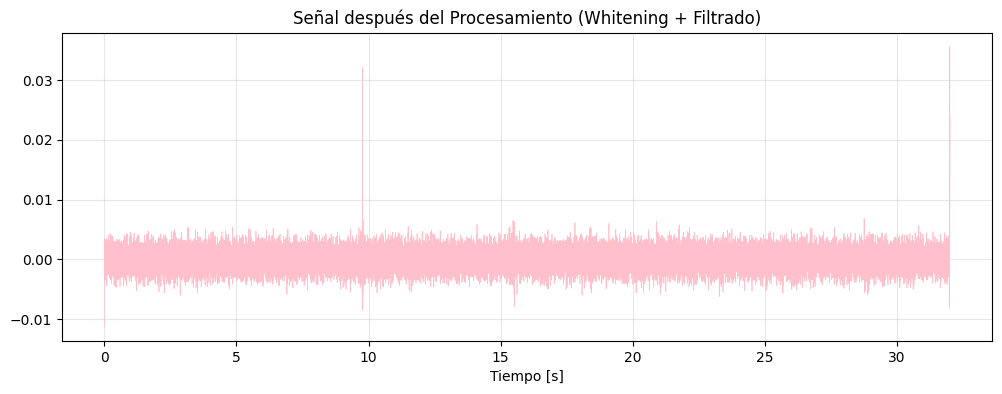

In [ ]:
# 4. PROCESAMIENTO
# Blanqueo
# Esta función aplana el ruido
def whitening_oficial(data, psd_data, f_psd_data, fs_rate):
    N_data = len(data)
    # rFFT para señales reales
    X = np.fft.rfft(data)
    f_fft = np.fft.rfftfreq(N_data, d=1/fs_rate)
    
    # INTERPOLACION
    psd_interp = np.interp(f_fft, f_psd_data, psd_data)
    
    # Blanqueo
    X_white = X / np.sqrt(psd_interp + 1e-12)
    
    # Regreso al tiempo
    x_white = np.fft.irfft(X_white, n=N_data)
    
    # Normalización por desviación estándar 
    return x_white / np.std(x_white)

#Aplicamos el Whitening
strain_w = whitening_oficial(strain, psd_l1, f_psd, fs)

#Filtrado Pasabanda
# Filtramos entre 30 y 350 Hz para aislar la onda gravitacional
b, a = signal.butter(4, [30, 350], btype='bandpass', fs=fs)
strain_f = signal.filtfilt(b, a, strain_w)

#Validación por Audio
# Normalizamos para que el CHIRP sea audible
strain_f_audible = strain_f / np.max(np.abs(strain_f))
wavfile.write('2_senal_procesada.wav', fs, strain_f_audible.astype(np.float32))

print("Procesamiento completado:")
print("- Ruido aplanado mediante Whitening.")
print("- Señal aislada con Filtro Butterworth (30-350 Hz).")
print("- Audio de validación generado.")

# Mostrar reproductor
ipd.display(ipd.Audio('2_senal_procesada.wav'))

#Gráfica de control
plt.figure(figsize=(12, 4))
plt.plot(time, strain_f, color='pink', lw=0.5)
plt.title('Señal después del Procesamiento (Whitening + Filtrado)')
plt.xlabel('Tiempo [s]')
plt.grid(alpha=0.3)
plt.show()

# Resampling
Para lograr una mejor definición de la señal, se debe hacer un resampleo. Esto tienen consecuencias por eso debe elegirse bien la frecuencia de tal forma que no se introduzca ruido.

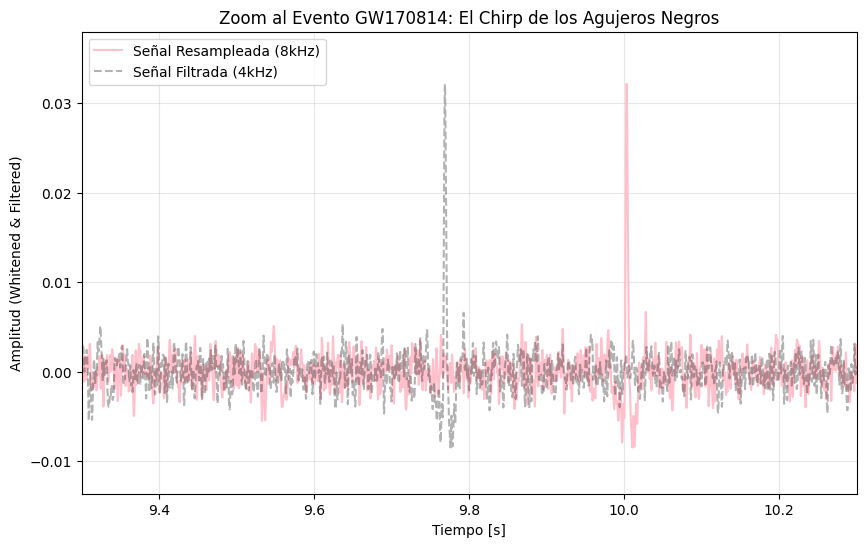

Resampling completado. Nueva frecuencia de muestreo: 8000 Hz.


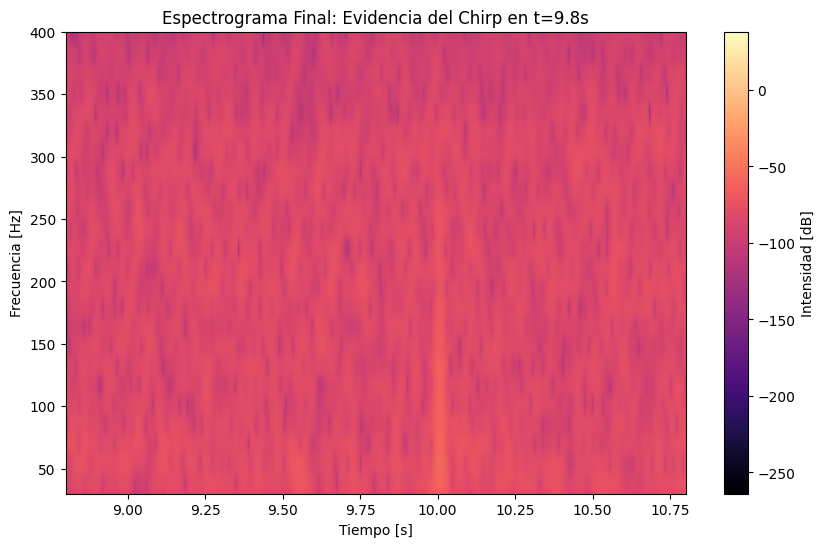

Audio Final: Señal con Resampling (8000 Hz)
Escucha con atención cerca del segundo 9.8 para validar el Chirp.


In [ ]:

# 5. RESAMPLING

# subiremos la frecuencia de 4000 Hz a 8000 Hz
# resample_poly aplica un filtro anti-aliasing automático
fs_new = 8000
strain_resampled = signal.resample_poly(strain_f, up=2, down=1)
time_resampled = np.arange(len(strain_resampled)) / fs_new

# VISUALIZACIÓN
# Hacemos zoom exacto donde ocurre el choque 
t_merger = 9.8

plt.figure(figsize=(10, 6))

# Graficamos la señal resampleada
plt.plot(time_resampled, strain_resampled, color='pink', label='Señal Resampleada (8kHz)', linewidth=1.5)

# comparamos la suavidad
plt.plot(time, strain_f, color='black', alpha=0.3, label='Señal Filtrada (4kHz)', linestyle='--')

plt.title('Zoom al Evento GW170814: El Chirp de los Agujeros Negros')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud (Whitened & Filtered)')
plt.xlim(t_merger - 0.5, t_merger + 0.5) # Zoom de 100ms
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Resampling completado. Nueva frecuencia de muestreo: {fs_new} Hz.")

plt.figure(figsize=(10, 6))

# Generamos el espectrograma
Pxx, freqs, bins, im = plt.specgram(
    strain_resampled, 
    NFFT=512, 
    Fs=fs_new, 
    noverlap=480, 
    cmap='magma'
)
# Calculamos la media para que el fondo sea oscuro
mean_val = np.mean(10 * np.log10(Pxx))
std_val = np.std(10 * np.log10(Pxx))

# Ajustamos el contraste
im.set_clim(mean_val - 2*std_val, mean_val + 5*std_val) 

plt.title(f'Espectrograma Final: Evidencia del Chirp en t={t_merger}s')
plt.xlim(t_merger - 1, t_merger + 1) 
plt.ylim(30, 400)
plt.ylabel('Frecuencia [Hz]')
plt.xlabel('Tiempo [s]')
plt.colorbar(label='Intensidad [dB]')
plt.show()
# VALIDACIÓN AUDITIVA FINAL

# Normalizamos la señal resampleada 
strain_final_audio = strain_resampled / np.max(np.abs(strain_resampled))

# Guardamos el archivo con la nueva frecuencia (8000 Hz)
wavfile.write('4_senal_final_resampled.wav', fs_new, strain_final_audio.astype(np.float32))

print("Audio Final: Señal con Resampling (8000 Hz)")
print(f"Escucha con atención cerca del segundo {t_merger} para validar el Chirp.")

# 3. Mostrar el reproductor
ipd.display(ipd.Audio('4_senal_final_resampled.wav'))

